<a href="https://colab.research.google.com/github/NehalShahu/Gen_AI/blob/main/NNDL_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

print("TensorFlow Version:", tf.__version__)

# Parameters
vocab_size = 10000      # Use the 10,000 most frequent words
max_length = 200        # Maximum review length

# Load IMDb dataset
(X_train, y_train), (X_test, y_test) = imdb.load_data(
    num_words=vocab_size
)

print("Dataset loaded successfully!")
print("Number of training reviews:", len(X_train))
print("Number of testing reviews:", len(X_test))


TensorFlow Version: 2.21.0
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Dataset loaded successfully!
Number of training reviews: 25000
Number of testing reviews: 25000


In [2]:
# Pad all reviews to the same length

X_train = pad_sequences(
    X_train,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

X_test = pad_sequences(
    X_test,
    maxlen=max_length,
    padding='post',
    truncating='post'
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nExample encoded review:")
print(X_train[0])

print("\nExample label:")
print("Positive" if y_train[0] == 1 else "Negative")


Training data shape: (25000, 200)
Testing data shape: (25000, 200)

Example encoded review:
[   1   14   22   16   43  530  973 1622 1385   65  458 4468   66 3941
    4  173   36  256    5   25  100   43  838  112   50  670    2    9
   35  480  284    5  150    4  172  112  167    2  336  385   39    4
  172 4536 1111   17  546   38   13  447    4  192   50   16    6  147
 2025   19   14   22    4 1920 4613  469    4   22   71   87   12   16
   43  530   38   76   15   13 1247    4   22   17  515   17   12   16
  626   18    2    5   62  386   12    8  316    8  106    5    4 2223
 5244   16  480   66 3785   33    4  130   12   16   38  619    5   25
  124   51   36  135   48   25 1415   33    6   22   12  215   28   77
   52    5   14  407   16   82    2    8    4  107  117 5952   15  256
    4    2    7 3766    5  723   36   71   43  530  476   26  400  317
   46    7    4    2 1029   13  104   88    4  381   15  297   98   32
 2071   56   26  141    6  194 7486   18    4  226   22 

In [3]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense

# Create RNN model
model = Sequential([

    # Convert word IDs into word vectors
    Embedding(
        input_dim=vocab_size,
        output_dim=32
    ),

    # Recurrent Neural Network layer
    SimpleRNN(32),

    # Output layer
    Dense(1, activation='sigmoid')
])

# Compile model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Display model architecture
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Train the model

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)

print("Model training completed!")


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 0.5028 - loss: 0.6946 - val_accuracy: 0.5004 - val_loss: 0.6934
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.6079 - loss: 0.6474 - val_accuracy: 0.4976 - val_loss: 0.7153
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7075 - loss: 0.4904 - val_accuracy: 0.5040 - val_loss: 0.8352
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7577 - loss: 0.3869 - val_accuracy: 0.5040 - val_loss: 0.9401
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.7764 - loss: 0.3527 - val_accuracy: 0.5044 - val_loss: 1.0456
Model training completed!


In [5]:
# Evaluate the trained model on unseen test data

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy * 100, 2), "%")


Test Loss: 1.0158
Test Accuracy: 51.22 %


In [6]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import seaborn as sns

# Predict probabilities
y_probability = model.predict(X_test, verbose=0)

# Convert probabilities into classes
y_pred = (y_probability >= 0.5).astype(int).flatten()

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"]
    )
)


Confusion Matrix:
[[4010 8490]
 [3705 8795]]

Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.32      0.40     12500
    Positive       0.51      0.70      0.59     12500

    accuracy                           0.51     25000
   macro avg       0.51      0.51      0.49     25000
weighted avg       0.51      0.51      0.49     25000



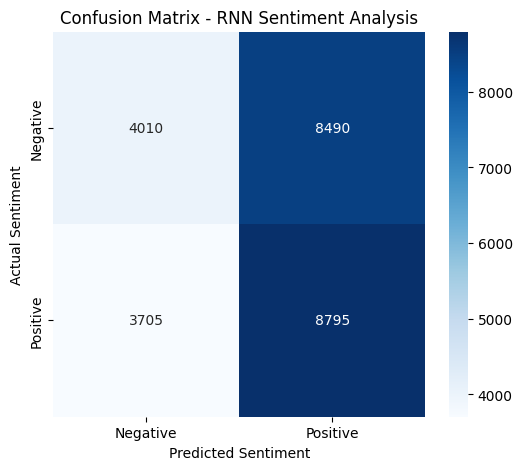

In [7]:
# Plot confusion matrix

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Negative', 'Positive'],
    yticklabels=['Negative', 'Positive']
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")
plt.title("Confusion Matrix - RNN Sentiment Analysis")

plt.show()


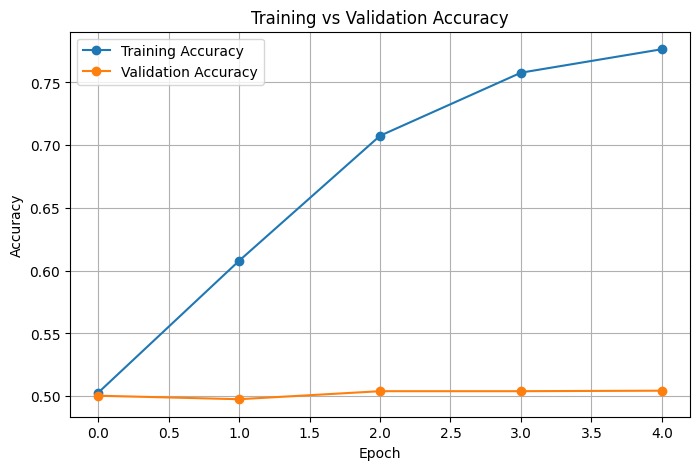

In [8]:
# Plot training and validation accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    marker='o',
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    marker='o',
    label='Validation Accuracy'
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid()

plt.show()


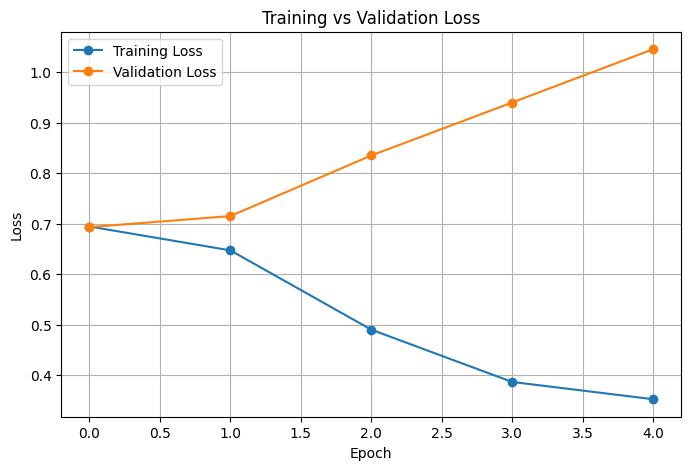

In [9]:
# Plot training and validation loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    marker='o',
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    marker='o',
    label='Validation Loss'
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid()

plt.show()


In [10]:
# Get IMDb word index
word_index = imdb.get_word_index()

def encode_review(text):
    words = text.lower().split()
    encoded = []

    for word in words:
        # Get word index
        index = word_index.get(word, 0)

        # IMDb index adjustment
        if index > 0:
            index = index + 3

        # Keep only words within vocabulary
        if index < vocab_size:
            encoded.append(index)
        else:
            encoded.append(2)  # Unknown word

    # Pad the review
    encoded = pad_sequences(
        [encoded],
        maxlen=max_length,
        padding='post',
        truncating='post'
    )

    return encoded


def predict_sentiment(text):
    # Convert text into model input
    encoded_text = encode_review(text)

    # Predict probability
    probability = model.predict(
        encoded_text,
        verbose=0
    )[0][0]

    # Determine sentiment
    if probability >= 0.5:
        sentiment = "Positive"
    else:
        sentiment = "Negative"

    print("Review:", text)
    print("Predicted Sentiment:", sentiment)
    print("Positive Probability:", round(float(probability), 4))


# Test example
predict_sentiment(
    "This movie was amazing and I really enjoyed it"
)


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Review: This movie was amazing and I really enjoyed it
Predicted Sentiment: Positive
Positive Probability: 0.5568
